In [34]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('../data/liveCodingData.csv')

df = pd.DataFrame(data)

df

,surface,prix
0,50,500000
1,52,520000
2,54,540000
3,56,560000
4,58,570000
...,...,...
96,242,1890000
97,244,1905000
98,246,1920000
99,248,1935000


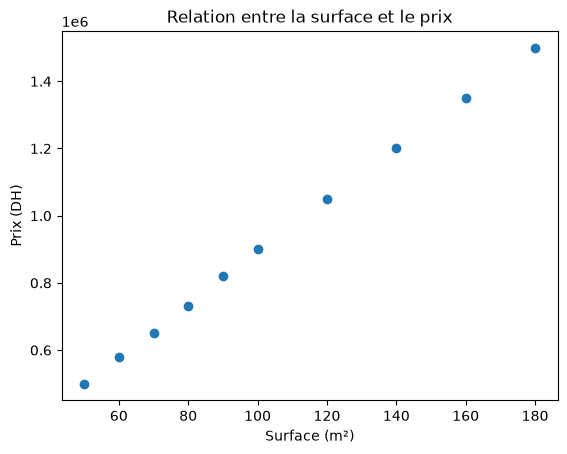

In [ ]:
plt.scatter(df['surface'], df['prix'])

plt.xlabel('Surface')
plt.ylabel('Prix MDH')
plt.title('Relation entre la surface et le prix')

plt.show()

In [28]:
from sklearn.model_selection import train_test_split

X = df[['surface']]
y = df['prix']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :")
print(X_train.shape)

print("\nX_test :")
print(X_test.shape)

print("\ny_train :")
print(y_train.shape)

print("\ny_test :")
print(y_test.shape)

X_train :
(80, 1)

X_test :
(21, 1)

y_train :
(80,)

y_test :
(21,)


In [17]:
from sklearn.linear_model import LinearRegression

# Créer le modèle
model = LinearRegression()

# Entraîner le modèle
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[7724.1]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['surface']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.174e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [ ]:
print("Coefficient :", model.coef_[0])

Coefficient : 7724.102564102567
Intercept : 117374.35897435865


In [31]:
y_pred = model.predict(X_test)
comparison = pd.DataFrame({
    'Prix réel': y_test.values,
    'Prix prédit': [int(i) for i in y_pred]
})

print(comparison)

    Prix réel  Prix prédit
0     1710000      1801228
1     1350000      1353230
2     1460000      1523161
3     1470000      1538609
4     1200000      1198748
5     1135000      1106059
6      850000       843440
7     1195000      1183300
8      650000       658061
9      500000       503579
10     780000       781647
11     990000       967025
12    1905000      2002055
13    1045000      1013370
14    1605000      1693091
15     570000       565372
16    1845000      1940262
17    1620000      1708539
18     680000       688957
19    1010000       982473
20    1590000      1677643


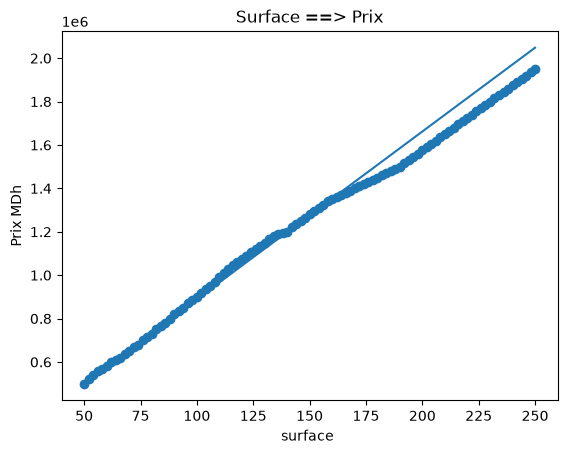

In [33]:
import matplotlib.pyplot as plt

plt.scatter(X, y, label='Données réelles')

plt.plot(
    X,
    model.predict(X),
    label='Droite de régression'
)
plt.xlabel('surface ')
plt.ylabel('Prix MDh')
plt.title('Surface ==> Prix')
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE :", mae)

MAE : 40013.18681318692
